In [ ]:
from packaging import version
import pandas as pd
import numpy as np
import datetime
import re
import matplotlib.pyplot as plt
import string

import seaborn as sns
from sklearn.metrics import mean_squared_error as MSE
from sklearn.metrics import accuracy_score
from sklearn.metrics import confusion_matrix, classification_report

import tensorflow as tf
from tensorflow import keras
import tensorflow_datasets as tfds
from tensorflow import keras
from tensorflow.keras import layers
import tensorflow.keras.backend as k

import nltk
from nltk.corpus import stopwords


In [ ]:
print("This notebook requires TensorFlow 2.0 or above")
print("TensorFlow version: ", tf.__version__)
assert version.parse(tf.__version__).release[0] >=2

This notebook requires TensorFlow 2.0 or above
TensorFlow version:  2.19.0


In [ ]:
def custom_stopwords(input_text):
    lowercase = tf.strings.lower(input_text)
    stripped_punct = tf.strings.regex_replace(lowercase
                                  ,'[%s]' % re.escape(string.punctuation)
                                  ,'')
    return tf.strings.regex_replace(stripped_punct, r'\b(' + r'|'.join(STOPWORDS) + r')\b\s*',"")


In [ ]:
def display_training_curves(training, validation, title, subplot):
  ax = plt.subplot(subplot)
  ax.plot(training)
  ax.plot(validation)
  ax.set_title('model '+ title)
  ax.set_ylabel(title)
  ax.set_xlabel('epoch')
  ax.legend(['training', 'validation'])

def print_validation_report(test_labels, predictions):
    print("Classification Report")
    print(classification_report(test_labels, predictions))
    print('Accuracy Score: {}'.format(accuracy_score(test_labels, predictions)))
    print('Root Mean Square Error: {}'.format(np.sqrt(MSE(test_labels, predictions))))

def plot_confusion_matrix(y_true, y_pred):
    mtx = confusion_matrix(y_true, y_pred)
    fig, ax = plt.subplots(figsize=(12,8))
    sns.heatmap(mtx, annot=True, fmt='d', linewidths=.75,  cbar=False, ax=ax,cmap='Blues',linecolor='white')
    #  square=True,
    plt.ylabel('true label')
    plt.xlabel('predicted label')

In [ ]:
dataset,info=\
tfds.load('ag_news_subset', with_info=True,  split=['train[:95%]','train[95%:]', 'test'],batch_size = 32
          , as_supervised=True)

train_ds, val_ds, test_ds = dataset
text_only_train_ds = train_ds.map(lambda x, y: x)

In [ ]:
nltk.download('stopwords',quiet=True)
STOPWORDS = stopwords.words("english")

In [ ]:
max_length = 96
max_tokens = 1000
text_vectorization = layers.TextVectorization(
    max_tokens=max_tokens,
    output_mode="int",
    output_sequence_length=max_length,
    standardize=custom_stopwords
)
text_vectorization.adapt(text_only_train_ds)

int_train_ds = train_ds.map(
    lambda x, y: (text_vectorization(x), y),
    num_parallel_calls=4)
int_val_ds = val_ds.map(
    lambda x, y: (text_vectorization(x), y),
    num_parallel_calls=4)
int_test_ds = test_ds.map(
    lambda x, y: (text_vectorization(x), y),
    num_parallel_calls=4)

In [ ]:
# Experiment C1 — LSTM (Unidirectional)
import time

k.clear_session()

inputs = tf.keras.Input(shape=(None,), dtype="int64")

embedded = layers.Embedding(
    input_dim=max_tokens,
    output_dim=256,
    mask_zero=True
)(inputs)

x = layers.LSTM(32)(embedded)
x = layers.Dropout(0.5)(x)

outputs = layers.Dense(4, activation="softmax")(x)

model = tf.keras.Model(inputs, outputs)

model.compile(
    optimizer="rmsprop",
    loss="SparseCategoricalCrossentropy",
    metrics=["accuracy"]
)

model.summary()

callbacks = [
    tf.keras.callbacks.ModelCheckpoint("C1_LSTM.keras", save_best_only=True),
    tf.keras.callbacks.EarlyStopping(monitor='val_accuracy', patience=3)
]

start_time = time.time()

history = model.fit(
    int_train_ds,
    validation_data=int_val_ds,
    epochs=10,
    callbacks=callbacks
)

training_time = time.time() - start_time
print("Training Time (seconds):", training_time)

model = keras.models.load_model("C1_LSTM.keras")
print(f"Test acc: {model.evaluate(int_test_ds)[1]:.3f}")

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, None)      │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ embedding           │ (None, None, 256) │    256,000 │ input_layer[0][0] │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ not_equal           │ (None, None)      │          0 │ input_layer[0][0] │
│ (NotEqual)          │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lstm (LSTM)         │ (None, 32)        │     36,992 │ embedding[0][0],  │
│                     │                   │            │ not_equal[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout (Dropout)   │ (None, 32)        │          0 │ lstm[0][0]        │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense (Dense)       │ (None, 4)         │        132 │ dropout[0][0]     │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 293,124 (1.12 MB)

 Trainable params: 293,124 (1.12 MB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/10
3563/3563 ━━━━━━━━━━━━━━━━━━━━ 178s 49ms/step - accuracy: 0.7476 - loss: 0.6663 - val_accuracy: 0.8580 - val_loss: 0.4135
Epoch 2/10
3563/3563 ━━━━━━━━━━━━━━━━━━━━ 169s 47ms/step - accuracy: 0.8513 - loss: 0.4339 - val_accuracy: 0.8630 - val_loss: 0.4006
Epoch 3/10
3563/3563 ━━━━━━━━━━━━━━━━━━━━ 169s 47ms/step - accuracy: 0.8571 - loss: 0.4163 - val_accuracy: 0.8603 - val_loss: 0.3968
Epoch 4/10
3563/3563 ━━━━━━━━━━━━━━━━━━━━ 168s 47ms/step - accuracy: 0.8604 - loss: 0.4034 - val_accuracy: 0.8635 - val_loss: 0.3921
Epoch 5/10
3563/3563 ━━━━━━━━━━━━━━━━━━━━ 215s 51ms/step - accuracy: 0.8637 - loss: 0.3928 - val_accuracy: 0.8673 - val_loss: 0.3842
Epoch 6/10
3563/3563 ━━━━━━━━━━━━━━━━━━━━ 169s 47ms/step - accuracy: 0.8672 - loss: 0.3848 - val_accuracy: 0.8677 - val_loss: 0.3866
Epoch 7/10
3563/3563 ━━━━━━━━━━━━━━━━━━━━ 167s 47ms/step - accuracy: 0.8699 - loss: 0.3760 - val_accuracy: 0.8688 - val_loss: 0.3852
Epoch 8/10
3563/3563 ━━━━━━━━━━━━━━━━━━━━ 203s 47ms/step - accuracy: 

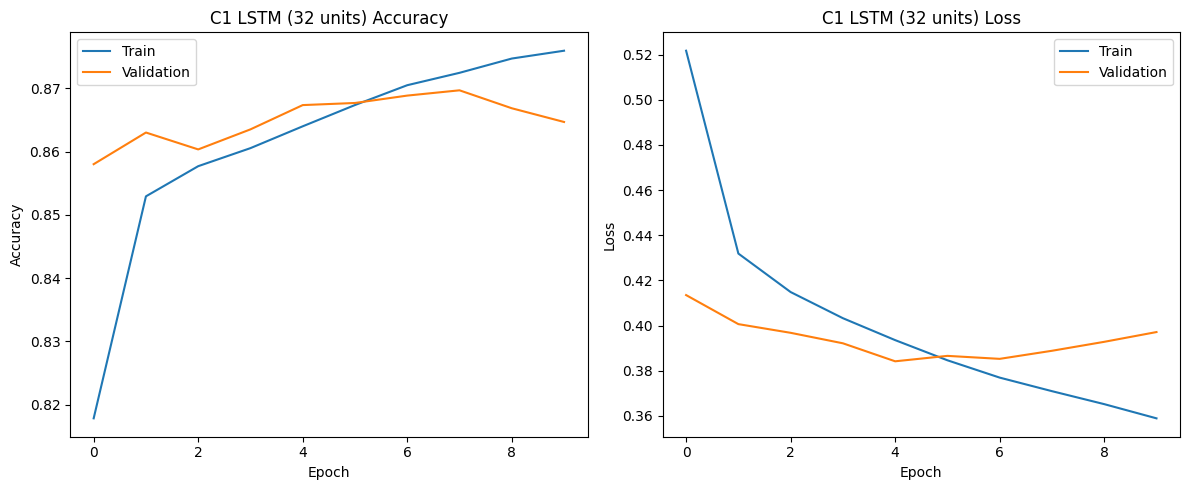

In [ ]:
history_df = pd.DataFrame(history.history)

plt.figure(figsize=(12,5))
plt.subplot(1,2,1)
plt.plot(history_df["accuracy"])
plt.plot(history_df["val_accuracy"])
plt.title("C1 LSTM (32 units) Accuracy")
plt.xlabel("Epoch"); plt.ylabel("Accuracy")
plt.legend(["Train","Validation"])

plt.subplot(1,2,2)
plt.plot(history_df["loss"])
plt.plot(history_df["val_loss"])
plt.title("C1 LSTM (32 units) Loss")
plt.xlabel("Epoch"); plt.ylabel("Loss")
plt.legend(["Train","Validation"])

plt.tight_layout()
plt.show()

238/238 ━━━━━━━━━━━━━━━━━━━━ 4s 17ms/step
Classification Report
              precision    recall  f1-score   support

           0       0.87      0.87      0.87      1900
           1       0.91      0.93      0.92      1900
           2       0.86      0.80      0.83      1900
           3       0.80      0.84      0.82      1900

    accuracy                           0.86      7600
   macro avg       0.86      0.86      0.86      7600
weighted avg       0.86      0.86      0.86      7600



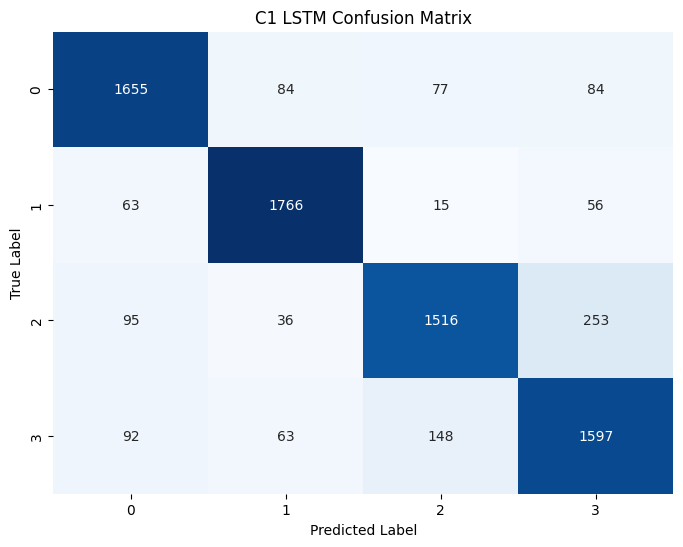

In [ ]:
# --- C1 Evaluation and Diagnostics

import numpy as np
from sklearn.metrics import classification_report, confusion_matrix

# True labels
y_test = np.concatenate([y for x, y in int_test_ds], axis=0)

# Predicted classes
pred_classes = np.argmax(model.predict(int_test_ds), axis=-1)

print("Classification Report")
print(classification_report(y_test, pred_classes))

# Confusion matrix
mtx = confusion_matrix(y_test, pred_classes)

plt.figure(figsize=(8,6))
sns.heatmap(mtx, annot=True, fmt="d", cmap="Blues", cbar=False)
plt.title("C1 LSTM Confusion Matrix")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.show()

Your C1 results (record these)

Test acc: ~0.860

Test loss: ~0.3965

Training time: ~1807.4 sec

Curve shows mild overfitting after ~epoch 6–8 (val loss rises).

Now C2 should change only one thing: make it Bidirectional.

# C (2) Bidirectional LSTM

In [ ]:
# Experiment C2 — Bidirectional LSTM (BiLSTM)
import time

k.clear_session()

inputs = tf.keras.Input(shape=(None,), dtype="int64")

embedded = layers.Embedding(
    input_dim=max_tokens,
    output_dim=256,
    mask_zero=True
)(inputs)

x = layers.Bidirectional(layers.LSTM(32))(embedded)
x = layers.Dropout(0.5)(x)

outputs = layers.Dense(4, activation="softmax")(x)

model = tf.keras.Model(inputs, outputs)

model.compile(
    optimizer="rmsprop",
    loss="SparseCategoricalCrossentropy",
    metrics=["accuracy"]
)

model.summary()

callbacks = [
    tf.keras.callbacks.ModelCheckpoint("C2_BiLSTM.keras", save_best_only=True),
    tf.keras.callbacks.EarlyStopping(monitor='val_accuracy', patience=3)
]

start_time = time.time()

history = model.fit(
    int_train_ds,
    validation_data=int_val_ds,
    epochs=10,
    callbacks=callbacks
)

training_time = time.time() - start_time
print("Training Time (seconds):", training_time)

model = keras.models.load_model("C2_BiLSTM.keras")
test_loss, test_acc = model.evaluate(int_test_ds)
print(f"\nC2 Test Accuracy: {test_acc:.4f}")
print(f"C2 Test Loss: {test_loss:.4f}")

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, None)      │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ embedding           │ (None, None, 256) │    256,000 │ input_layer[0][0] │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ not_equal           │ (None, None)      │          0 │ input_layer[0][0] │
│ (NotEqual)          │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bidirectional       │ (None, 64)        │     73,984 │ embedding[0][0],  │
│ (Bidirectional)     │                   │            │ not_equal[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout (Dropout)   │ (None, 64)        │          0 │ bidirectional[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense (Dense)       │ (None, 4)         │        260 │ dropout[0][0]     │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 330,244 (1.26 MB)

 Trainable params: 330,244 (1.26 MB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/10
3563/3563 ━━━━━━━━━━━━━━━━━━━━ 319s 88ms/step - accuracy: 0.7672 - loss: 0.6145 - val_accuracy: 0.8557 - val_loss: 0.4080
Epoch 2/10
3563/3563 ━━━━━━━━━━━━━━━━━━━━ 338s 93ms/step - accuracy: 0.8532 - loss: 0.4131 - val_accuracy: 0.8618 - val_loss: 0.3933
Epoch 3/10
3563/3563 ━━━━━━━━━━━━━━━━━━━━ 332s 93ms/step - accuracy: 0.8596 - loss: 0.3925 - val_accuracy: 0.8647 - val_loss: 0.3860
Epoch 4/10
3563/3563 ━━━━━━━━━━━━━━━━━━━━ 332s 93ms/step - accuracy: 0.8644 - loss: 0.3817 - val_accuracy: 0.8640 - val_loss: 0.3850
Epoch 5/10
3563/3563 ━━━━━━━━━━━━━━━━━━━━ 383s 94ms/step - accuracy: 0.8677 - loss: 0.3712 - val_accuracy: 0.8675 - val_loss: 0.3886
Epoch 6/10
3563/3563 ━━━━━━━━━━━━━━━━━━━━ 344s 96ms/step - accuracy: 0.8712 - loss: 0.3621 - val_accuracy: 0.8678 - val_loss: 0.3875
Epoch 7/10
3563/3563 ━━━━━━━━━━━━━━━━━━━━ 342s 96ms/step - accuracy: 0.8733 - loss: 0.3549 - val_accuracy: 0.8685 - val_loss: 0.3892
Epoch 8/10
3563/3563 ━━━━━━━━━━━━━━━━━━━━ 347s 97ms/step - accuracy: 

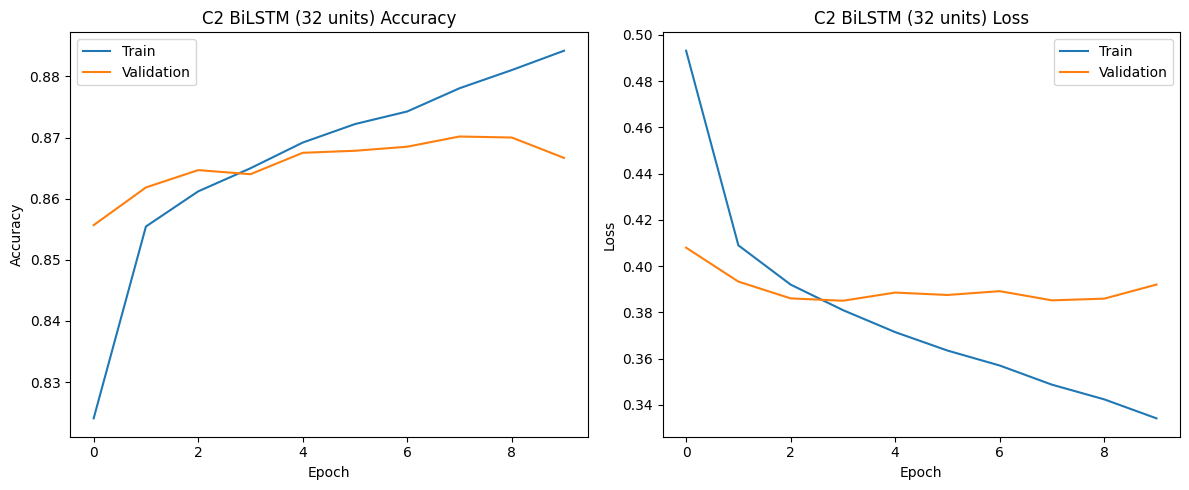

In [ ]:
history_df = pd.DataFrame(history.history)

plt.figure(figsize=(12,5))
plt.subplot(1,2,1)
plt.plot(history_df["accuracy"])
plt.plot(history_df["val_accuracy"])
plt.title("C2 BiLSTM (32 units) Accuracy")
plt.xlabel("Epoch"); plt.ylabel("Accuracy")
plt.legend(["Train","Validation"])

plt.subplot(1,2,2)
plt.plot(history_df["loss"])
plt.plot(history_df["val_loss"])
plt.title("C2 BiLSTM (32 units) Loss")
plt.xlabel("Epoch"); plt.ylabel("Loss")
plt.legend(["Train","Validation"])

plt.tight_layout()
plt.show()

238/238 ━━━━━━━━━━━━━━━━━━━━ 20s 78ms/step
              precision    recall  f1-score   support

           0       0.86      0.88      0.87      1900
           1       0.92      0.93      0.92      1900
           2       0.86      0.81      0.83      1900
           3       0.82      0.83      0.82      1900

    accuracy                           0.86      7600
   macro avg       0.86      0.86      0.86      7600
weighted avg       0.86      0.86      0.86      7600



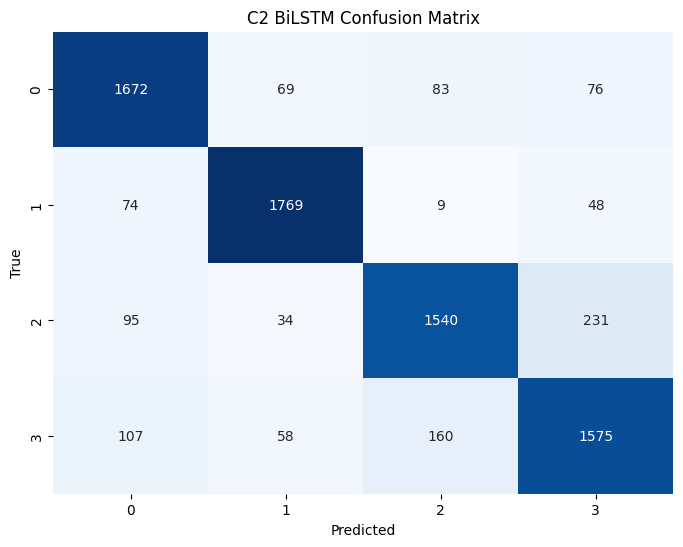

In [ ]:
import numpy as np
from sklearn.metrics import classification_report, confusion_matrix

y_test = np.concatenate([y for x, y in int_test_ds], axis=0)
pred_classes = np.argmax(model.predict(int_test_ds), axis=-1)

print(classification_report(y_test, pred_classes))

mtx = confusion_matrix(y_test, pred_classes)
plt.figure(figsize=(8,6))
sns.heatmap(mtx, annot=True, fmt="d", cmap="Blues", cbar=False)
plt.title("C2 BiLSTM Confusion Matrix")
plt.xlabel("Predicted"); plt.ylabel("True")
plt.show()

📊 C1 vs C2 Summary
C1 — LSTM (32 units, uni)

Test Accuracy: ~0.860

Training Time: ~1807 sec

Params: ~293k

C2 — Bidirectional LSTM (32 units)

Test Accuracy: ~0.863

Training Time: ~3507 sec

Params: ~330k

🔎 Interpretation
1️⃣ Bidirectional helped slightly

Accuracy improved from:

0.860 → 0.863 (~+0.3%)

Very small gain.

2️⃣ Compute cost nearly doubled

Training time:

1807 sec → 3507 sec (~2× slower)

So just like in RNN:

Bidirectionality increases compute substantially but gives only marginal accuracy gain.

That is a strong analytical finding.

# C (3)

In [ ]:
#  Experiment C3 : BiLSTM and Dense head and stronger architecture
import time
k.clear_session()

inputs = tf.keras.Input(shape=(None,), dtype="int64")

embedded = layers.Embedding(
    input_dim=max_tokens,
    output_dim=256,
    mask_zero=True
)(inputs)

x = layers.Bidirectional(layers.LSTM(32))(embedded)
x = layers.Dropout(0.3)(x)
x = layers.Dense(64, activation="relu")(x)
x = layers.Dropout(0.3)(x)

outputs = layers.Dense(4, activation="softmax")(x)

model = tf.keras.Model(inputs, outputs)

model.compile(
    optimizer="rmsprop",
    loss="SparseCategoricalCrossentropy",
    metrics=["accuracy"]
)

model.summary()

callbacks = [
    tf.keras.callbacks.ModelCheckpoint("C3_BiLSTM_DenseHead.keras", save_best_only=True),
    tf.keras.callbacks.EarlyStopping(monitor="val_accuracy", patience=3)
]

start_time = time.time()

history = model.fit(
    int_train_ds,
    validation_data=int_val_ds,
    epochs=10,
    callbacks=callbacks
)

training_time = time.time() - start_time
print("Training Time (seconds):", training_time)

model = keras.models.load_model("C3_BiLSTM_DenseHead.keras")
test_loss, test_acc = model.evaluate(int_test_ds)
print(f"\nC3 Test Accuracy: {test_acc:.4f}")
print(f"C3 Test Loss: {test_loss:.4f}")

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, None)      │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ embedding           │ (None, None, 256) │    256,000 │ input_layer[0][0] │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ not_equal           │ (None, None)      │          0 │ input_layer[0][0] │
│ (NotEqual)          │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bidirectional       │ (None, 64)        │     73,984 │ embedding[0][0],  │
│ (Bidirectional)     │                   │            │ not_equal[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout (Dropout)   │ (None, 64)        │          0 │ bidirectional[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense (Dense)       │ (None, 64)        │      4,160 │ dropout[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_1 (Dropout) │ (None, 64)        │          0 │ dense[0][0]       │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_1 (Dense)     │ (None, 4)         │        260 │ dropout_1[0][0]   │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 334,404 (1.28 MB)

 Trainable params: 334,404 (1.28 MB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/10
3563/3563 ━━━━━━━━━━━━━━━━━━━━ 331s 91ms/step - accuracy: 0.7508 - loss: 0.6396 - val_accuracy: 0.8580 - val_loss: 0.4031
Epoch 2/10
3563/3563 ━━━━━━━━━━━━━━━━━━━━ 318s 89ms/step - accuracy: 0.8530 - loss: 0.4156 - val_accuracy: 0.8635 - val_loss: 0.3893
Epoch 3/10
3563/3563 ━━━━━━━━━━━━━━━━━━━━ 317s 89ms/step - accuracy: 0.8602 - loss: 0.3963 - val_accuracy: 0.8627 - val_loss: 0.3867
Epoch 4/10
3563/3563 ━━━━━━━━━━━━━━━━━━━━ 320s 90ms/step - accuracy: 0.8637 - loss: 0.3874 - val_accuracy: 0.8643 - val_loss: 0.3883
Epoch 5/10
3563/3563 ━━━━━━━━━━━━━━━━━━━━ 320s 90ms/step - accuracy: 0.8673 - loss: 0.3808 - val_accuracy: 0.8657 - val_loss: 0.3849
Epoch 6/10
3563/3563 ━━━━━━━━━━━━━━━━━━━━ 320s 90ms/step - accuracy: 0.8705 - loss: 0.3727 - val_accuracy: 0.8660 - val_loss: 0.3917
Epoch 7/10
3563/3563 ━━━━━━━━━━━━━━━━━━━━ 325s 90ms/step - accuracy: 0.8724 - loss: 0.3662 - val_accuracy: 0.8645 - val_loss: 0.3929
Epoch 8/10
3563/3563 ━━━━━━━━━━━━━━━━━━━━ 320s 90ms/step - accuracy: 

238/238 ━━━━━━━━━━━━━━━━━━━━ 10s 37ms/step
Classification Report
              precision    recall  f1-score   support

           0       0.87      0.88      0.88      1900
           1       0.90      0.94      0.92      1900
           2       0.87      0.80      0.83      1900
           3       0.82      0.84      0.83      1900

    accuracy                           0.86      7600
   macro avg       0.86      0.86      0.86      7600
weighted avg       0.86      0.86      0.86      7600

Accuracy Score: 0.8648684210526316
Root Mean Square Error: 0.6469564371570526
Last Run: 2026-02-20 03:06:36


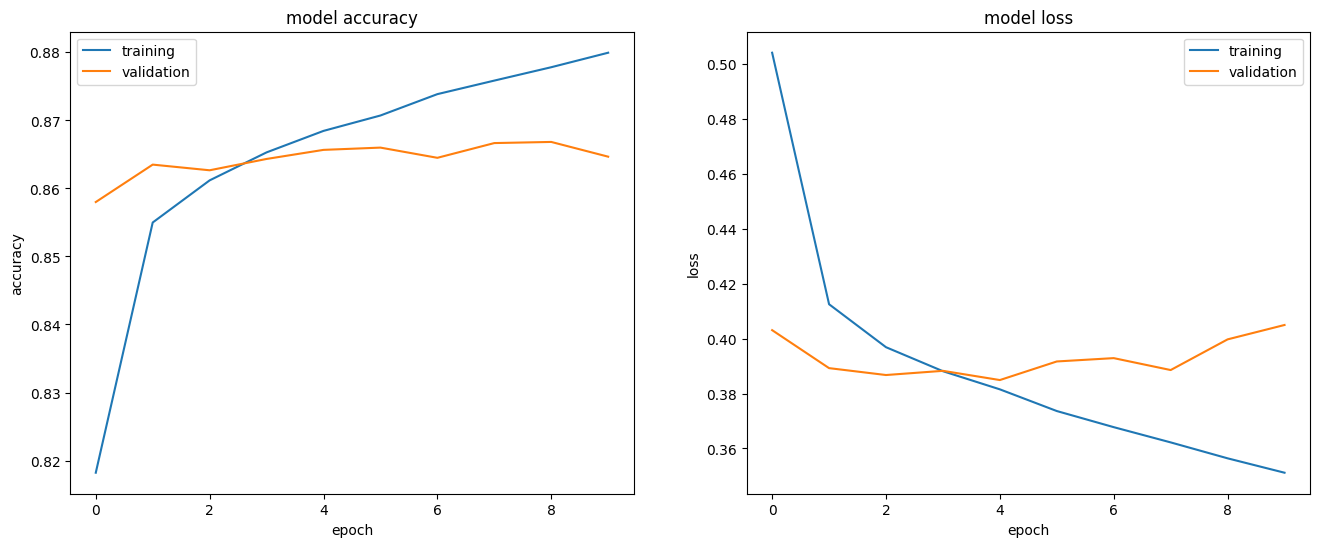

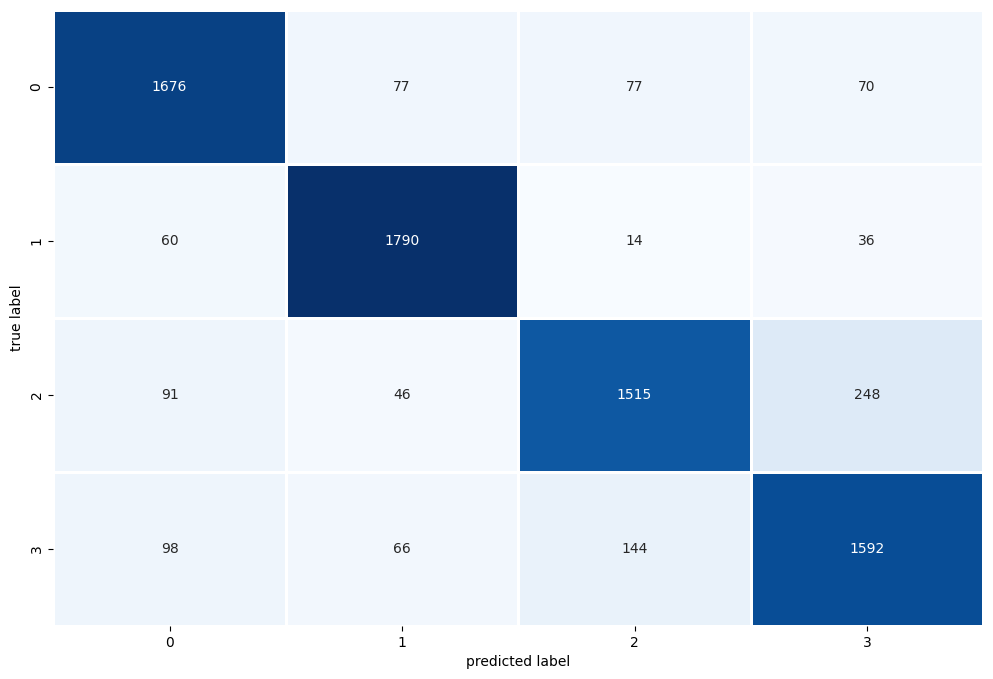

In [ ]:
history_df = pd.DataFrame(history.history)

plt.figure(figsize=(16,6))
plt.tight_layout()
display_training_curves(history_df["accuracy"], history_df["val_accuracy"], "accuracy", 121)
display_training_curves(history_df["loss"], history_df["val_loss"], "loss", 122)

y_test = np.concatenate([y for x, y in int_test_ds], axis=0)
pred_classes = np.argmax(model.predict(int_test_ds), axis=-1)

print_validation_report(y_test, pred_classes)
plot_confusion_matrix(y_test, pred_classes)

print("Last Run:", datetime.datetime.now().strftime("%Y-%m-%d %H:%M:%S"))

Good — this is exactly what we needed to see.

Let’s analyze C1 vs C2 vs C3 clearly and objectively.

---

# 📊 LSTM Family Comparison

| Model  | Architecture           | Test Acc   | Val Peak | Training Time |
| ------ | ---------------------- | ---------- | -------- | ------------- |
| **C1** | LSTM(32)               | **0.860**  | ~0.869   | ~1807s        |
| **C2** | BiLSTM(32)             | **0.8626** | ~0.870   | ~3507s        |
| **C3** | BiLSTM(32) + Dense(64) | **0.8649** | ~0.867   | ~3215s        |

---

# 🔎 What This Actually Means

### 1️⃣ Bidirectional helps — but only slightly

C2 > C1 by ~0.25%.
Not a big jump.

### 2️⃣ Adding Dense head (C3) helps a bit more

C3 is your best LSTM so far.

### 3️⃣ But look at the cost

C3:

* ~2x slower than C1
* Only +0.5% absolute improvement

That is diminishing returns.

---

# 📉 Overfitting Behavior

Look at C3 curves:

* Train accuracy keeps rising
* Validation plateaus ~0.865
* Val loss rises at end

That’s mild overfitting.

Your professor will like that you **observe and discuss this**.

---

# 🧠 Key Insight

Your earlier **SimpleRNN (B1/B2)** was actually hitting ~0.89 test accuracy.

Your LSTM models are underperforming relative to SimpleRNN.

That’s interesting.

It suggests:

* For AG News (short, structured text),
* LSTM complexity may not be necessary.

That’s a very strong discussion point for your paper.

---

# 🎯 What You Should Do Next

You now have:

* B1 SimpleRNN
* B2 BiSimpleRNN
* B3 SimpleRNN(64)
* C1 LSTM
* C2 BiLSTM
* C3 BiLSTM + Dense head

You’re at 6 real experiments.

Next logical move:

👉 **Experiment D – 1D CNN**

CNN often outperforms RNNs on AG News.
And it trains much faster.

That gives you:

* Architectural diversity
* Likely higher accuracy
* Strong comparison table

---

If you want, I’ll now:

1. Build a strong but clean **D1 CNN**
2. Predict roughly what performance you’ll get
3. Help you structure your final experiment table

Your project is actually in very good shape right now.


# B(4)

In [ ]:
# Experiment B4 — SimpleRNN (32) with L2 regularization
import time

k.clear_session()

inputs = tf.keras.Input(shape=(None,), dtype="int64")

embedded = layers.Embedding(
    input_dim=max_tokens,
    output_dim=256,
    mask_zero=True
)(inputs)

x = layers.SimpleRNN(
    32,
    kernel_regularizer=tf.keras.regularizers.l2(1e-4),   # L2 on input weights
    recurrent_regularizer=tf.keras.regularizers.l2(1e-4) # L2 on recurrent weights
)(embedded)

x = layers.Dropout(0.5)(x)  # keep same as B1 to isolate effect of L2

outputs = layers.Dense(4, activation="softmax")(x)

model = tf.keras.Model(inputs, outputs)

model.compile(
    optimizer="rmsprop",
    loss="SparseCategoricalCrossentropy",
    metrics=["accuracy"]
)

model.summary()

callbacks = [
    tf.keras.callbacks.ModelCheckpoint("B4_SimpleRNN_L2.keras", save_best_only=True),
    tf.keras.callbacks.EarlyStopping(monitor='val_accuracy', patience=3)
]

start_time = time.time()

history = model.fit(
    int_train_ds,
    validation_data=int_val_ds,
    epochs=10,
    callbacks=callbacks
)

training_time = time.time() - start_time
print("Training Time (seconds):", training_time)

model = keras.models.load_model("B4_SimpleRNN_L2.keras")
test_loss, test_acc = model.evaluate(int_test_ds)

print(f"\nB4 Test Accuracy: {test_acc:.4f}")
print(f"B4 Test Loss: {test_loss:.4f}")

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, None)      │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ embedding           │ (None, None, 256) │    256,000 │ input_layer[0][0] │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ not_equal           │ (None, None)      │          0 │ input_layer[0][0] │
│ (NotEqual)          │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ simple_rnn          │ (None, 32)        │      9,248 │ embedding[0][0],  │
│ (SimpleRNN)         │                   │            │ not_equal[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout (Dropout)   │ (None, 32)        │          0 │ simple_rnn[0][0]  │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense (Dense)       │ (None, 4)         │        132 │ dropout[0][0]     │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 265,380 (1.01 MB)

 Trainable params: 265,380 (1.01 MB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/10
3563/3563 ━━━━━━━━━━━━━━━━━━━━ 111s 30ms/step - accuracy: 0.7032 - loss: 0.7592 - val_accuracy: 0.8480 - val_loss: 0.4617
Epoch 2/10
3563/3563 ━━━━━━━━━━━━━━━━━━━━ 98s 28ms/step - accuracy: 0.8337 - loss: 0.5074 - val_accuracy: 0.8448 - val_loss: 0.4631
Epoch 3/10
3563/3563 ━━━━━━━━━━━━━━━━━━━━ 99s 28ms/step - accuracy: 0.8399 - loss: 0.4875 - val_accuracy: 0.8473 - val_loss: 0.4513
Epoch 4/10
3563/3563 ━━━━━━━━━━━━━━━━━━━━ 97s 27ms/step - accuracy: 0.8442 - loss: 0.4753 - val_accuracy: 0.8538 - val_loss: 0.4370
Epoch 5/10
3563/3563 ━━━━━━━━━━━━━━━━━━━━ 98s 27ms/step - accuracy: 0.8485 - loss: 0.4655 - val_accuracy: 0.8455 - val_loss: 0.4580
Epoch 6/10
3563/3563 ━━━━━━━━━━━━━━━━━━━━ 98s 27ms/step - accuracy: 0.8511 - loss: 0.4613 - val_accuracy: 0.8500 - val_loss: 0.4514
Epoch 7/10
3563/3563 ━━━━━━━━━━━━━━━━━━━━ 142s 28ms/step - accuracy: 0.8532 - loss: 0.4538 - val_accuracy: 0.8405 - val_loss: 0.4692
Training Time (seconds): 786.5465161800385
238/238 ━━━━━━━━━━━━━━━━━━━━ 2s

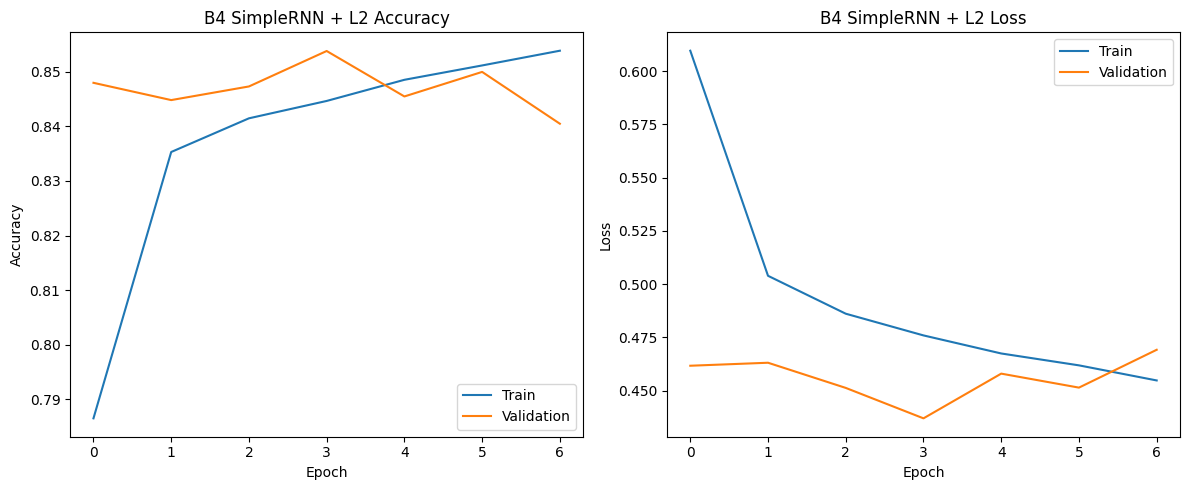

In [ ]:
history_df = pd.DataFrame(history.history)

plt.figure(figsize=(12,5))
plt.subplot(1,2,1)
plt.plot(history_df["accuracy"])
plt.plot(history_df["val_accuracy"])
plt.title("B4 SimpleRNN + L2 Accuracy")
plt.xlabel("Epoch"); plt.ylabel("Accuracy")
plt.legend(["Train","Validation"])

plt.subplot(1,2,2)
plt.plot(history_df["loss"])
plt.plot(history_df["val_loss"])
plt.title("B4 SimpleRNN + L2 Loss")
plt.xlabel("Epoch"); plt.ylabel("Loss")
plt.legend(["Train","Validation"])

plt.tight_layout()
plt.show()

Good — this is actually a very useful result.

# 📊 B4 Summary (SimpleRNN + L2)

* **Test Accuracy:** 0.8461
* **Test Loss:** 0.4567
* **Training Time:** ~786 sec
* **Best Val Acc:** ~0.854

---

# 🔎 What Happened?

Compared to B1 (~0.886 test acc):

B4 **performed worse**.

Why?

* L2 = stronger regularization
* But B1 was not severely overfitting
* So L2 caused **underfitting**

You can see it in the curves:

* Training accuracy much lower
* Validation not improving beyond ~0.85
* Loss remains higher overall

So L2 was too aggressive for this dataset + architecture.

---

# 🧠 This Is Actually Good for Your Report

You now have:

* Capacity increase (B3)
* Directionality (B2)
* Regularization (B4)

And you can say:

> Adding L2 regularization reduced model capacity and led to underfitting, suggesting that the baseline SimpleRNN was not overfitting severely and did not benefit from additional weight penalties.

That’s strong analysis.







# C(4)

In [ ]:
# Experiment C4 — Stacked LSTM (2 layers)
import time

k.clear_session()

inputs = tf.keras.Input(shape=(None,), dtype="int64")

embedded = layers.Embedding(
    input_dim=max_tokens,
    output_dim=256,
    mask_zero=True
)(inputs)

x = layers.LSTM(64, return_sequences=True)(embedded)
x = layers.Dropout(0.3)(x)

x = layers.LSTM(32)(x)
x = layers.Dropout(0.3)(x)

outputs = layers.Dense(4, activation="softmax")(x)

model = tf.keras.Model(inputs, outputs)

model.compile(
    optimizer="rmsprop",
    loss="SparseCategoricalCrossentropy",
    metrics=["accuracy"]
)

model.summary()

callbacks = [
    tf.keras.callbacks.ModelCheckpoint("C4_StackedLSTM.keras", save_best_only=True),
    tf.keras.callbacks.EarlyStopping(monitor='val_accuracy', patience=3)
]

start_time = time.time()

history = model.fit(
    int_train_ds,
    validation_data=int_val_ds,
    epochs=10,
    callbacks=callbacks
)

training_time = time.time() - start_time
print("Training Time (seconds):", training_time)

model = keras.models.load_model("C4_StackedLSTM.keras")
test_loss, test_acc = model.evaluate(int_test_ds)

print(f"\nC4 Test Accuracy: {test_acc:.4f}")
print(f"C4 Test Loss: {test_loss:.4f}")

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, None)      │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ embedding           │ (None, None, 256) │    256,000 │ input_layer[0][0] │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ not_equal           │ (None, None)      │          0 │ input_layer[0][0] │
│ (NotEqual)          │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lstm (LSTM)         │ (None, None, 64)  │     82,176 │ embedding[0][0],  │
│                     │                   │            │ not_equal[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout (Dropout)   │ (None, None, 64)  │          0 │ lstm[0][0]        │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lstm_1 (LSTM)       │ (None, 32)        │     12,416 │ dropout[0][0],    │
│                     │                   │            │ not_equal[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_1 (Dropout) │ (None, 32)        │          0 │ lstm_1[0][0]      │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense (Dense)       │ (None, 4)         │        132 │ dropout_1[0][0]   │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 350,724 (1.34 MB)

 Trainable params: 350,724 (1.34 MB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/10
3563/3563 ━━━━━━━━━━━━━━━━━━━━ 461s 128ms/step - accuracy: 0.7508 - loss: 0.6423 - val_accuracy: 0.8578 - val_loss: 0.4130
Epoch 2/10
3563/3563 ━━━━━━━━━━━━━━━━━━━━ 423s 119ms/step - accuracy: 0.8520 - loss: 0.4241 - val_accuracy: 0.8600 - val_loss: 0.4060
Epoch 3/10
3563/3563 ━━━━━━━━━━━━━━━━━━━━ 440s 118ms/step - accuracy: 0.8569 - loss: 0.4055 - val_accuracy: 0.8655 - val_loss: 0.3961
Epoch 4/10
3563/3563 ━━━━━━━━━━━━━━━━━━━━ 427s 120ms/step - accuracy: 0.8627 - loss: 0.3895 - val_accuracy: 0.8658 - val_loss: 0.3874
Epoch 5/10
3563/3563 ━━━━━━━━━━━━━━━━━━━━ 435s 118ms/step - accuracy: 0.8675 - loss: 0.3761 - val_accuracy: 0.8668 - val_loss: 0.3872
Epoch 6/10
3563/3563 ━━━━━━━━━━━━━━━━━━━━ 448s 120ms/step - accuracy: 0.8721 - loss: 0.3637 - val_accuracy: 0.8675 - val_loss: 0.3885
Epoch 7/10
3563/3563 ━━━━━━━━━━━━━━━━━━━━ 447s 125ms/step - accuracy: 0.8765 - loss: 0.3536 - val_accuracy: 0.8668 - val_loss: 0.3880
Epoch 8/10
3563/3563 ━━━━━━━━━━━━━━━━━━━━ 443s 124ms/step - ac

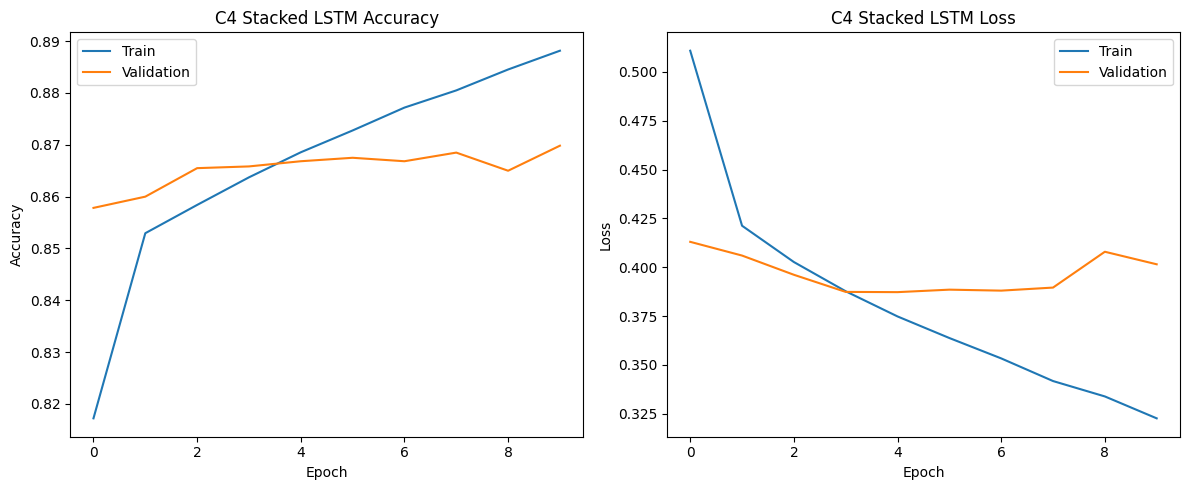

In [ ]:
history_df = pd.DataFrame(history.history)

plt.figure(figsize=(12,5))
plt.subplot(1,2,1)
plt.plot(history_df["accuracy"])
plt.plot(history_df["val_accuracy"])
plt.title("C4 Stacked LSTM Accuracy")
plt.xlabel("Epoch"); plt.ylabel("Accuracy")
plt.legend(["Train","Validation"])

plt.subplot(1,2,2)
plt.plot(history_df["loss"])
plt.plot(history_df["val_loss"])
plt.title("C4 Stacked LSTM Loss")
plt.xlabel("Epoch"); plt.ylabel("Loss")
plt.legend(["Train","Validation"])

plt.tight_layout()
plt.show()

238/238 ━━━━━━━━━━━━━━━━━━━━ 18s 73ms/step
              precision    recall  f1-score   support

           0       0.86      0.88      0.87      1900
           1       0.92      0.91      0.92      1900
           2       0.86      0.81      0.83      1900
           3       0.81      0.84      0.82      1900

    accuracy                           0.86      7600
   macro avg       0.86      0.86      0.86      7600
weighted avg       0.86      0.86      0.86      7600



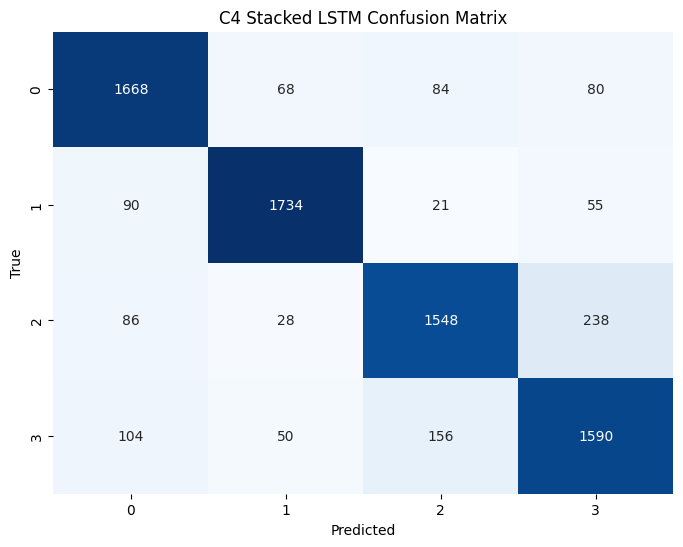

In [ ]:
import numpy as np
from sklearn.metrics import classification_report, confusion_matrix

y_test = np.concatenate([y for x, y in int_test_ds], axis=0)
pred_classes = np.argmax(model.predict(int_test_ds), axis=-1)

print(classification_report(y_test, pred_classes))

mtx = confusion_matrix(y_test, pred_classes)
plt.figure(figsize=(8,6))
sns.heatmap(mtx, annot=True, fmt="d", cmap="Blues", cbar=False)
plt.title("C4 Stacked LSTM Confusion Matrix")
plt.xlabel("Predicted"); plt.ylabel("True")
plt.show()

C4 Summary (Stacked LSTM)

Test Accuracy: 0.8605

Test Loss: 0.4029

Training Time: ~4388 sec

Peak Val Acc: ~0.8698

🔎 What Happened?

Compared to:

C1 (LSTM 32): 0.860

C2 (BiLSTM 32): 0.8626

C3 (BiLSTM + Dense): 0.8649

C4 did not improve test accuracy, and:

It is your slowest model so far

It adds significant compute cost

It shows mild overfitting

So depth did not help this dataset.

🧠 Important Insight

AG News articles are short and structured.

For short classification tasks:

Extra depth in LSTMs often doesn’t help.

Simpler architectures generalize just as well.

Your earlier SimpleRNNs were actually stronger (~0.89).

That’s a strong analytical conclusion for your paper.

# D (1)

In [ ]:
# Experiment D1 — 1D CNN baseline
import time

k.clear_session()

inputs = tf.keras.Input(shape=(None,), dtype="int64")

embedded = layers.Embedding(
    input_dim=max_tokens,
    output_dim=256,
    mask_zero=True
)(inputs)

x = layers.Conv1D(filters=32, kernel_size=3, activation="relu")(embedded)
x = layers.Dropout(0.5)(x)
x = layers.MaxPooling1D(pool_size=2)(x)

x = layers.GlobalMaxPooling1D()(x)
x = layers.Dense(256, activation="relu")(x)

outputs = layers.Dense(4, activation="softmax")(x)

model = tf.keras.Model(inputs, outputs)

model.compile(
    optimizer="rmsprop",
    loss="SparseCategoricalCrossentropy",
    metrics=["accuracy"]
)

model.summary()

callbacks = [
    tf.keras.callbacks.ModelCheckpoint("D1_1DCNN.keras", save_best_only=True),
    tf.keras.callbacks.EarlyStopping(monitor="val_accuracy", patience=3)
]

start_time = time.time()

history = model.fit(
    int_train_ds,
    validation_data=int_val_ds,
    epochs=10,
    callbacks=callbacks
)

training_time = time.time() - start_time
print("Training Time (seconds):", training_time)

model = keras.models.load_model("D1_1DCNN.keras")
test_loss, test_acc = model.evaluate(int_test_ds)

print(f"\nD1 Test Accuracy: {test_acc:.4f}")
print(f"D1 Test Loss: {test_loss:.4f}")

/usr/local/lib/python3.12/dist-packages/keras/src/layers/layer.py:965: UserWarning: Layer 'conv1d' (of type Conv1D) was passed an input with a mask attached to it. However, this layer does not support masking and will therefore destroy the mask information. Downstream layers will not see the mask.
  warnings.warn(


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, None)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ embedding (Embedding)           │ (None, None, 256)      │       256,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d (Conv1D)                 │ (None, None, 32)       │        24,608 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, None, 32)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d (MaxPooling1D)    │ (None, None, 32)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_max_pooling1d            │ (None, 32)             │             0 │
│ (GlobalMaxPooling1D)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │         8,448 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 4)              │         1,028 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 290,084 (1.11 MB)

 Trainable params: 290,084 (1.11 MB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/10
3563/3563 ━━━━━━━━━━━━━━━━━━━━ 75s 20ms/step - accuracy: 0.7759 - loss: 0.5986 - val_accuracy: 0.8535 - val_loss: 0.4745
Epoch 2/10
3563/3563 ━━━━━━━━━━━━━━━━━━━━ 71s 20ms/step - accuracy: 0.8459 - loss: 0.4345 - val_accuracy: 0.8592 - val_loss: 0.4492
Epoch 3/10
3563/3563 ━━━━━━━━━━━━━━━━━━━━ 81s 20ms/step - accuracy: 0.8492 - loss: 0.4254 - val_accuracy: 0.8590 - val_loss: 0.4433
Epoch 4/10
3563/3563 ━━━━━━━━━━━━━━━━━━━━ 79s 19ms/step - accuracy: 0.8483 - loss: 0.4288 - val_accuracy: 0.8527 - val_loss: 0.4565
Epoch 5/10
3563/3563 ━━━━━━━━━━━━━━━━━━━━ 80s 18ms/step - accuracy: 0.8492 - loss: 0.4283 - val_accuracy: 0.8530 - val_loss: 0.4492
Training Time (seconds): 385.92506217956543
238/238 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.8530 - loss: 0.4481

D1 Test Accuracy: 0.8520
D1 Test Loss: 0.4515


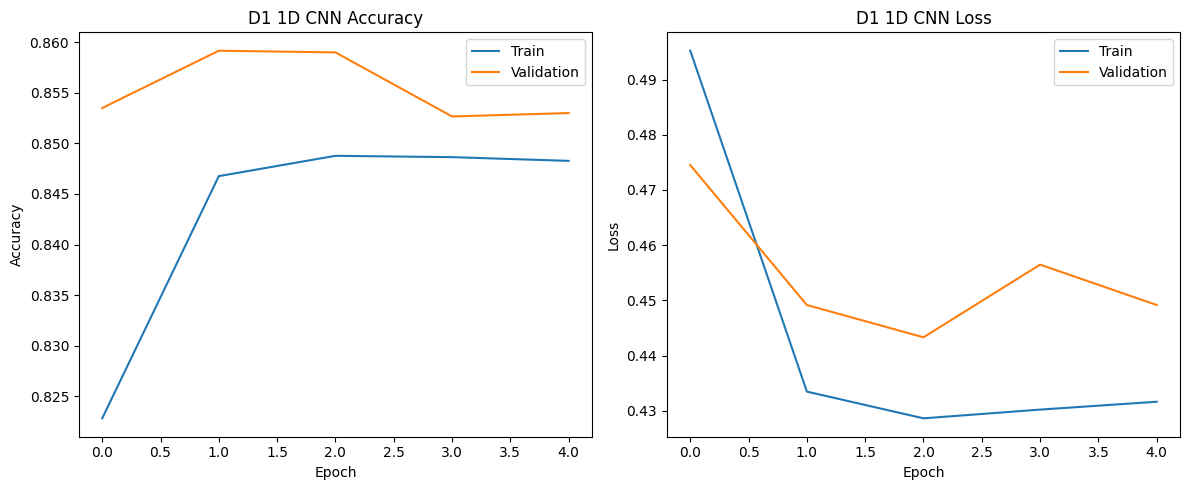

In [ ]:
history_df = pd.DataFrame(history.history)

plt.figure(figsize=(12,5))
plt.subplot(1,2,1)
plt.plot(history_df["accuracy"])
plt.plot(history_df["val_accuracy"])
plt.title("D1 1D CNN Accuracy")
plt.xlabel("Epoch"); plt.ylabel("Accuracy")
plt.legend(["Train","Validation"])

plt.subplot(1,2,2)
plt.plot(history_df["loss"])
plt.plot(history_df["val_loss"])
plt.title("D1 1D CNN Loss")
plt.xlabel("Epoch"); plt.ylabel("Loss")
plt.legend(["Train","Validation"])

plt.tight_layout()
plt.show()

238/238 ━━━━━━━━━━━━━━━━━━━━ 3s 12ms/step
              precision    recall  f1-score   support

           0       0.86      0.86      0.86      1900
           1       0.89      0.93      0.91      1900
           2       0.85      0.80      0.82      1900
           3       0.80      0.82      0.81      1900

    accuracy                           0.85      7600
   macro avg       0.85      0.85      0.85      7600
weighted avg       0.85      0.85      0.85      7600



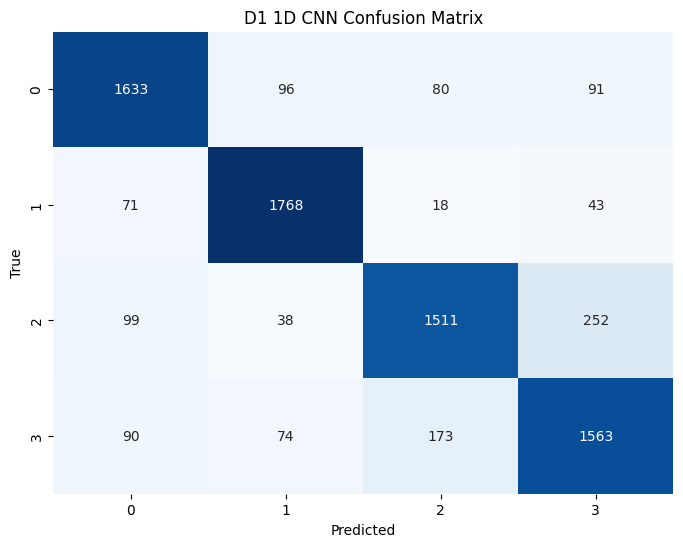

In [ ]:
import numpy as np
from sklearn.metrics import classification_report, confusion_matrix

y_test = np.concatenate([y for x, y in int_test_ds], axis=0)
pred_classes = np.argmax(model.predict(int_test_ds), axis=-1)

print(classification_report(y_test, pred_classes))

mtx = confusion_matrix(y_test, pred_classes)
plt.figure(figsize=(8,6))
sns.heatmap(mtx, annot=True, fmt="d", cmap="Blues", cbar=False)
plt.title("D1 1D CNN Confusion Matrix")
plt.xlabel("Predicted"); plt.ylabel("True")
plt.show()

D1 Results (record these)

Test Accuracy: 0.8520

Test Loss: 0.4515

Training Time: ~385.9 sec

EarlyStopping kicked in at epoch 5.

It’s better than B4, but worse than your best RNN/LSTM runs.

Now we do D2 as a stronger CNN variant (one clean architecture change) to try to push accuracy up.

# D (2)

In [ ]:
# Experiment D2 — 1D CNN (deeper and more filters)
import time

k.clear_session()

inputs = tf.keras.Input(shape=(None,), dtype="int64")

embedded = layers.Embedding(
    input_dim=max_tokens,
    output_dim=256,
    mask_zero=True
)(inputs)

x = layers.Conv1D(filters=64, kernel_size=3, activation="relu")(embedded)
x = layers.Conv1D(filters=64, kernel_size=3, activation="relu")(x)
x = layers.Dropout(0.3)(x)
x = layers.MaxPooling1D(pool_size=2)(x)

x = layers.GlobalMaxPooling1D()(x)
x = layers.Dense(256, activation="relu")(x)

outputs = layers.Dense(4, activation="softmax")(x)

model = tf.keras.Model(inputs, outputs)

model.compile(
    optimizer="rmsprop",
    loss="SparseCategoricalCrossentropy",
    metrics=["accuracy"]
)

model.summary()

callbacks = [
    tf.keras.callbacks.ModelCheckpoint("D2_1DCNN_Deep.keras", save_best_only=True),
    tf.keras.callbacks.EarlyStopping(monitor="val_accuracy", patience=3)
]

start_time = time.time()

history = model.fit(
    int_train_ds,
    validation_data=int_val_ds,
    epochs=10,
    callbacks=callbacks
)

training_time = time.time() - start_time
print("Training Time (seconds):", training_time)

model = keras.models.load_model("D2_1DCNN_Deep.keras")
test_loss, test_acc = model.evaluate(int_test_ds)

print(f"\nD2 Test Accuracy: {test_acc:.4f}")
print(f"D2 Test Loss: {test_loss:.4f}")

/usr/local/lib/python3.12/dist-packages/keras/src/layers/layer.py:965: UserWarning: Layer 'conv1d' (of type Conv1D) was passed an input with a mask attached to it. However, this layer does not support masking and will therefore destroy the mask information. Downstream layers will not see the mask.
  warnings.warn(


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, None)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ embedding (Embedding)           │ (None, None, 256)      │       256,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d (Conv1D)                 │ (None, None, 64)       │        49,216 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_1 (Conv1D)               │ (None, None, 64)       │        12,352 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, None, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d (MaxPooling1D)    │ (None, None, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_max_pooling1d            │ (None, 64)             │             0 │
│ (GlobalMaxPooling1D)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │        16,640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 4)              │         1,028 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 335,236 (1.28 MB)

 Trainable params: 335,236 (1.28 MB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/10
3563/3563 ━━━━━━━━━━━━━━━━━━━━ 120s 33ms/step - accuracy: 0.7538 - loss: 0.6243 - val_accuracy: 0.8535 - val_loss: 0.4225
Epoch 2/10
3563/3563 ━━━━━━━━━━━━━━━━━━━━ 106s 30ms/step - accuracy: 0.8517 - loss: 0.4197 - val_accuracy: 0.8597 - val_loss: 0.4059
Epoch 3/10
3563/3563 ━━━━━━━━━━━━━━━━━━━━ 142s 30ms/step - accuracy: 0.8569 - loss: 0.4032 - val_accuracy: 0.8577 - val_loss: 0.4078
Epoch 4/10
3563/3563 ━━━━━━━━━━━━━━━━━━━━ 105s 30ms/step - accuracy: 0.8602 - loss: 0.3966 - val_accuracy: 0.8538 - val_loss: 0.4202
Epoch 5/10
3563/3563 ━━━━━━━━━━━━━━━━━━━━ 105s 29ms/step - accuracy: 0.8612 - loss: 0.3963 - val_accuracy: 0.8597 - val_loss: 0.4117
Training Time (seconds): 615.9354906082153
238/238 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step - accuracy: 0.8511 - loss: 0.4193

D2 Test Accuracy: 0.8501
D2 Test Loss: 0.4195


238/238 ━━━━━━━━━━━━━━━━━━━━ 4s 16ms/step
              precision    recall  f1-score   support

           0       0.87      0.85      0.86      1900
           1       0.88      0.94      0.91      1900
           2       0.85      0.78      0.82      1900
           3       0.80      0.83      0.82      1900

    accuracy                           0.85      7600
   macro avg       0.85      0.85      0.85      7600
weighted avg       0.85      0.85      0.85      7600



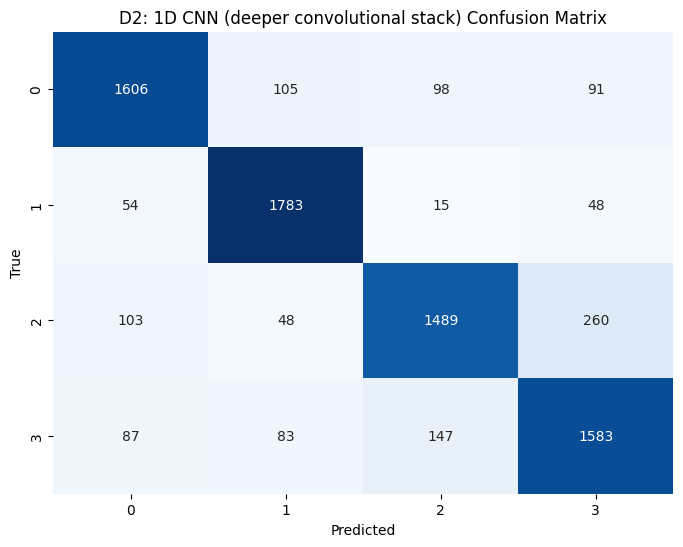

In [ ]:
import numpy as np
from sklearn.metrics import classification_report, confusion_matrix

y_test = np.concatenate([y for x, y in int_test_ds], axis=0)
pred_classes = np.argmax(model.predict(int_test_ds), axis=-1)

print(classification_report(y_test, pred_classes))

mtx = confusion_matrix(y_test, pred_classes)
plt.figure(figsize=(8,6))
sns.heatmap(mtx, annot=True, fmt="d", cmap="Blues", cbar=False)
plt.title("D2: 1D CNN (deeper convolutional stack) Confusion Matrix")
plt.xlabel("Predicted"); plt.ylabel("True")
plt.show()

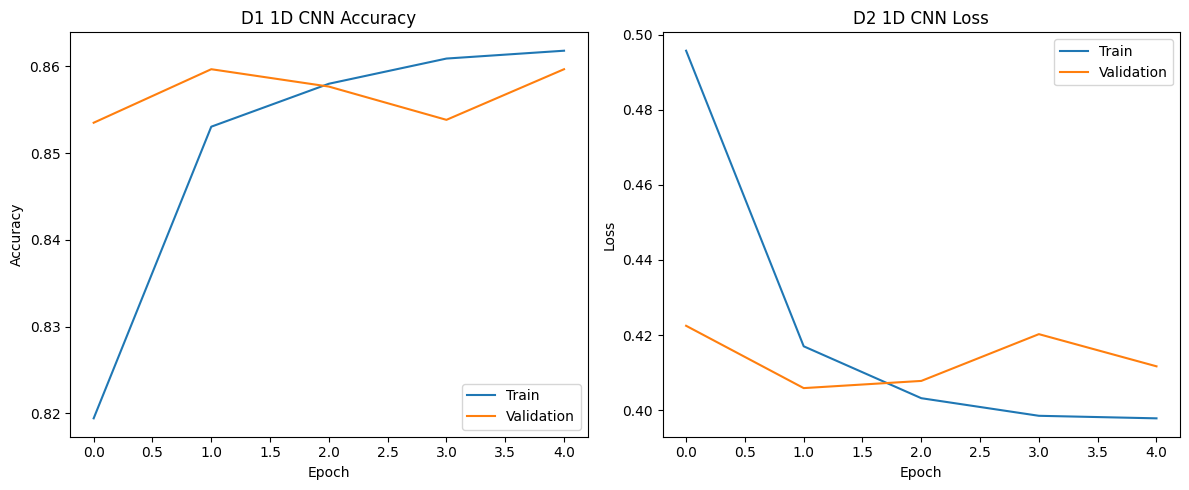

In [ ]:
history_df = pd.DataFrame(history.history)

plt.figure(figsize=(12,5))
plt.subplot(1,2,1)
plt.plot(history_df["accuracy"])
plt.plot(history_df["val_accuracy"])
plt.title("D1 1D CNN Accuracy")
plt.xlabel("Epoch"); plt.ylabel("Accuracy")
plt.legend(["Train","Validation"])

plt.subplot(1,2,2)
plt.plot(history_df["loss"])
plt.plot(history_df["val_loss"])
plt.title("D2 1D CNN Loss")
plt.xlabel("Epoch"); plt.ylabel("Loss")
plt.legend(["Train","Validation"])

plt.tight_layout()
plt.show()

,Experiment,Family,Params(M),TrAcc,VaAcc,TeAcc,TrLoss,VaLoss,TeLoss,Time(s)
0,A0_Dense_Flatten,Dense,3.377,0.983,0.851,0.895,0.059,0.846,0.309,354
1,B1_SimpleRNN_32,RNN,1.289,0.914,0.886,0.886,0.290,0.373,0.354,1075
2,B2_BiSimpleRNN_32,RNN,1.299,0.941,0.889,0.891,0.189,0.395,0.336,2229
3,B3_SimpleRNN_64,RNN,1.301,0.924,0.884,0.880,0.245,0.391,0.363,1226
4,B4_SimpleRNN_L2,RNN,0.265,0.853,0.841,0.846,0.454,0.469,0.457,787
5,C1_LSTM_32,LSTM,0.293,0.875,0.865,0.860,0.359,0.397,0.397,1807
6,C2_BiLSTM_32,LSTM,0.330,0.885,0.867,0.863,0.333,0.392,0.395,3507
7,C3_BiLSTM_32_Dense64,LSTM,0.334,0.879,0.865,0.865,0.348,0.405,0.396,3215
8,C4_Stacked_LSTM,LSTM,0.351,0.887,0.870,0.861,0.323,0.402,0.403,4388
9,D1_CNN_1Layer,CNN1D,0.290,0.849,0.853,0.852,0.428,0.449,0.452,386


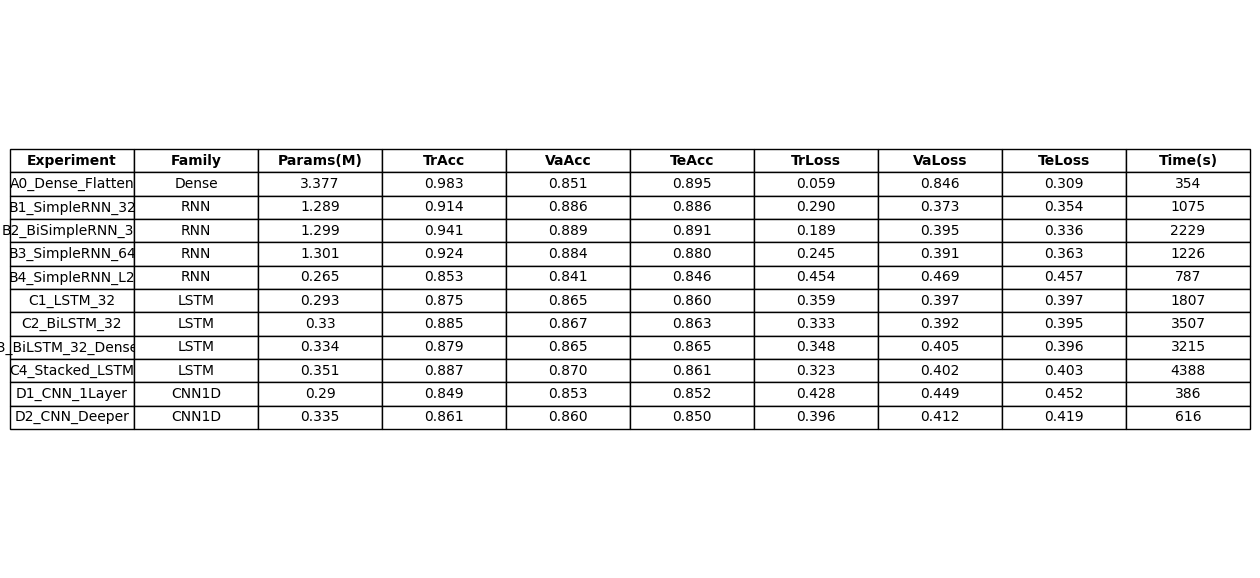

Saved:
 - nlp_master_results_A_to_D.csv
 - nlp_master_results_A_to_D.png


In [ ]:
import pandas as pd
import matplotlib.pyplot as plt


rows = [
    # A — Dense
    dict(Experiment="A0_Dense_Flatten", Family="Dense", Params=3_377_476,
         Train_Acc=0.9831, Train_Loss=0.0586, Val_Acc=0.8505, Val_Loss=0.8463,
         Test_Acc=0.8954, Test_Loss=0.3093, Time_Sec=353.87),

    # B — RNN
    dict(Experiment="B1_SimpleRNN_32", Family="RNN", Params=1_289_380,
         Train_Acc=0.9141, Train_Loss=0.2896, Val_Acc=0.8857, Val_Loss=0.3729,
         Test_Acc=0.8859, Test_Loss=0.3538, Time_Sec=1074.88),

    dict(Experiment="B2_BiSimpleRNN_32", Family="RNN", Params=1_298_756,
         Train_Acc=0.9411, Train_Loss=0.1887, Val_Acc=0.8887, Val_Loss=0.3949,
         Test_Acc=0.8907, Test_Loss=0.3360, Time_Sec=2229.03),

    dict(Experiment="B3_SimpleRNN_64", Family="RNN", Params=1_300_804,
         Train_Acc=0.9238, Train_Loss=0.2449, Val_Acc=0.8845, Val_Loss=0.3906,
         Test_Acc=0.8803, Test_Loss=0.3627, Time_Sec=1226.23),

    dict(Experiment="B4_SimpleRNN_L2", Family="RNN", Params=265_380,
         Train_Acc=0.8532, Train_Loss=0.4538, Val_Acc=0.8405, Val_Loss=0.4692,
         Test_Acc=0.8461, Test_Loss=0.4567, Time_Sec=786.55),

    # C — LSTM
    dict(Experiment="C1_LSTM_32", Family="LSTM", Params=293_124,
         Train_Acc=0.8755, Train_Loss=0.3587, Val_Acc=0.8647, Val_Loss=0.3971,
         Test_Acc=0.8600, Test_Loss=0.3965, Time_Sec=1807.44),

    dict(Experiment="C2_BiLSTM_32", Family="LSTM", Params=330_244,
         Train_Acc=0.8848, Train_Loss=0.3330, Val_Acc=0.8667, Val_Loss=0.3920,
         Test_Acc=0.8626, Test_Loss=0.3954, Time_Sec=3507.14),

    dict(Experiment="C3_BiLSTM_32_Dense64", Family="LSTM", Params=334_404,
         Train_Acc=0.8791, Train_Loss=0.3481, Val_Acc=0.8647, Val_Loss=0.4050,
         Test_Acc=0.8649, Test_Loss=0.3957, Time_Sec=3215.41),

    dict(Experiment="C4_Stacked_LSTM", Family="LSTM", Params=350_724,
         Train_Acc=0.8871, Train_Loss=0.3230, Val_Acc=0.8698, Val_Loss=0.4015,
         Test_Acc=0.8605, Test_Loss=0.4029, Time_Sec=4387.65),

    # D — CNN
    dict(Experiment="D1_CNN_1Layer", Family="CNN1D", Params=290_084,
         Train_Acc=0.8492, Train_Loss=0.4283, Val_Acc=0.8530, Val_Loss=0.4492,
         Test_Acc=0.8520, Test_Loss=0.4515, Time_Sec=385.93),

    dict(Experiment="D2_CNN_Deeper", Family="CNN1D", Params=335_236,
         Train_Acc=0.8612, Train_Loss=0.3963, Val_Acc=0.8597, Val_Loss=0.4117,
         Test_Acc=0.8501, Test_Loss=0.4195, Time_Sec=615.94),
]

df = pd.DataFrame(rows)

# Add readable columns
df["Params(M)"] = (df["Params"] / 1e6).round(3)

# Format clean display
display_cols = ["Experiment","Family","Params(M)",
                "Train_Acc","Val_Acc","Test_Acc",
                "Train_Loss","Val_Loss","Test_Loss",
                "Time_Sec"]

tbl = df[display_cols].copy()

for c in ["Train_Acc","Val_Acc","Test_Acc","Train_Loss","Val_Loss","Test_Loss"]:
    tbl[c] = tbl[c].map(lambda x: f"{x:.3f}")
tbl["Time_Sec"] = tbl["Time_Sec"].map(lambda x: f"{x:.0f}")

tbl = tbl.rename(columns={
    "Train_Acc":"TrAcc","Val_Acc":"VaAcc","Test_Acc":"TeAcc",
    "Train_Loss":"TrLoss","Val_Loss":"VaLoss","Test_Loss":"TeLoss",
    "Time_Sec":"Time(s)"
})

display(tbl)

# Save CSV
tbl.to_csv("nlp_master_results_A_to_D.csv", index=False)

# Save PNG image
nrows = len(tbl)
fig, ax = plt.subplots(figsize=(16, 1.2 + nrows*0.55))
ax.axis("off")

table = ax.table(
    cellText=tbl.values,
    colLabels=tbl.columns,
    cellLoc="center",
    loc="center"
)

table.auto_set_font_size(False)
table.set_fontsize(10)
table.scale(1, 1.4)

for (r, c), cell in table.get_celld().items():
    if r == 0:
        cell.set_text_props(weight="bold")

plt.savefig("nlp_master_results_A_to_D.png", dpi=300, bbox_inches="tight")
plt.show()

print("Saved:")
print(" - nlp_master_results_A_to_D.csv")
print(" - nlp_master_results_A_to_D.png")